In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation
import copy
from scipy.stats         import chi2, norm

from gammapy.data import DataStore
from gammapy.maps import MapAxis, RegionGeom, Map
from gammapy.makers import ReflectedRegionsBackgroundMaker, SafeMaskMaker, SpectrumDatasetMaker, WobbleRegionsFinder
from gammapy.datasets import Datasets, FluxPointsDataset, SpectrumDataset
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator, FluxPointsEstimator, LightCurveEstimator, FluxPoints
from gammapy.modeling.models import (
    LogParabolaSpectralModel, FoVBackgroundModel, GaussianSpatialModel, Models,
    PiecewiseNormSpectralModel, PointSpatialModel, PowerLawSpectralModel, SkyModel,
    create_crab_spectral_model
)
from gammapy.modeling import Fit

from regions import PointSkyRegion, CircleSkyRegion
from gammapy.utils.regions import compound_region_to_regions

import warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*color.*override.*")

from gammapy import __version__ as gammapy_version

print(f"Using gammapy version: v{gammapy_version}")

Using gammapy version: v1.1


We define intially the main information we need for the source to be analysed.

In [2]:
source_name = "Crab"
source_coord = SkyCoord.from_name(source_name)


# dl3_path = f"/fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.10.9/Gamma/prod_standard/__DL3"
dl3_path = f"/fefs/aswg/workspace/juan.jimenez/data/real/mono/Crab/v0.10.9/Gamma/prod_standard/__DL3scaled"

Reading the data using `gammapy`:
* `DataStore()` (data_store) contains the data directories and the observation informations.
* `Observations()` (obs_collection) contains the IRF data itself.

You can modify `obs_id` to select specific set of runs for the analysis.

In [3]:
data_store = DataStore.from_dir(dl3_path)
obs_ids = data_store.obs_ids
print(f"Obs IDs in directory is {obs_ids}")

obs_collection = data_store.get_observations(obs_ids, required_irf="all-optional")

print(f"Total livetime : {data_store.obs_table['LIVETIME'].to(u.h).sum():.2f}")

Obs IDs in directory is [21404 21405 21726 21727 21816 21921 21922 21923 21924 21925 21926 21939
 21940 21941 21942 21943 21951 22049 22050 22051 22052 22053 22060 22326
 22327 22569 22598 22599 22740 22741 22825 22826 22827 23039 23049 23087
 23088 23089 23090 23091 23093 23094 23095 23281 23282 23283 23284 23432
 23491 23492 23493 23559 23560 23561 23562 23662 23666 23667 23668 23669
 23670 23671 23896 23897 23898 23955 23956 23958 23992 23996]
Total livetime : 16.59 h


We can read HDUs information using `data_store.hdu_table`, as well as run information `data_store.obs_table`. Here you can check that `RAD_MAX` HDU is available, as is needed for `point-like` analysis.

In [4]:
display(data_store.hdu_table)
display(data_store.obs_table)

OBS_ID,HDU_TYPE,HDU_CLASS,FILE_DIR,FILE_NAME,HDU_NAME,SIZE
int64,bytes8,bytes8,bytes1,bytes23,bytes17,int64
21404,events,events,.,dl3_LST-1.Run21404.fits,EVENTS,227520
21404,gti,gti,.,dl3_LST-1.Run21404.fits,GTI,227520
21404,pointing,pointing,.,dl3_LST-1.Run21404.fits,POINTING,227520
21404,aeff,aeff_2d,.,dl3_LST-1.Run21404.fits,EFFECTIVE AREA,227520
21404,edisp,edisp_2d,.,dl3_LST-1.Run21404.fits,ENERGY DISPERSION,227520
...,...,...,...,...,...,...
23996,events,events,.,dl3_LST-1.Run23996.fits,EVENTS,455040
23996,gti,gti,.,dl3_LST-1.Run23996.fits,GTI,455040
23996,pointing,pointing,.,dl3_LST-1.Run23996.fits,POINTING,455040


OBS_ID,DATE-OBS,TIME-OBS,DATE-END,TIME-END,RA_PNT,DEC_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,RA_OBJ,DEC_OBJ,TSTART,TSTOP,ONTIME,TELAPSE,LIVETIME,DEADC,OBJECT,OBS_MODE,N_TELS,TELLIST,INSTRUME
,,,,,deg,deg,deg,deg,deg,deg,deg,s,s,s,s,s,,,,,,
int64,bytes10,bytes12,bytes10,bytes12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes4,bytes8,int64,bytes5,bytes5
21404,2025-08-19,05:00:46.973,2025-08-19,05:10:30.905,83.96956389740177,22.249421215849402,52.27511264578506,37.72488735421494,83.00052658243565,83.6324,22.0174,217227646.97330546,217228230.90544537,584.6574137210846,583.932139903307,580.4113984918089,0.9927376013206577,Crab,POINTING,1,LST-1,LST-1
21405,2025-08-19,05:11:02.308,2025-08-19,05:20:31.503,83.27226168178248,21.776470582999288,49.614585971366836,40.385414028633164,84.86714844905504,83.6324,22.0174,217228262.30771878,217228831.50259545,569.7415442466736,569.1948766708374,564.528819317523,0.9908507199768222,Crab,POINTING,1,LST-1,LST-1
21726,2025-09-02,04:20:01.513,2025-09-02,04:38:41.479,83.97367747016148,22.248759789512842,48.11739570036227,41.88260429963773,84.93359980625547,83.6324,22.0174,218434801.51345277,218435921.4790869,1107.6092793941498,1119.965634137392,1041.5641219823324,0.9403714300335734,Crab,POINTING,1,LST-1,LST-1
21727,2025-09-02,04:39:14.142,2025-09-02,04:41:45.120,83.27986554393709,21.780941223307845,45.27147725619655,44.72852274380345,86.9744769816334,83.6324,22.0174,218435954.14168957,218436105.1197102,150.99811816215515,150.97802063822746,142.72727909282798,0.9452255487022347,Crab,POINTING,1,LST-1,LST-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23955,2026-03-10,22:12:17.148,2026-03-10,22:26:06.701,83.99690165924366,22.246254149546,37.492541495463485,52.507458504536515,269.68358315896535,83.6324,22.0174,234828737.1476879,234829566.70141435,825.7578983306885,829.5537264347076,783.6548190744521,0.9490128046715025,Crab,POINTING,1,LST-1,LST-1
23956,2026-03-10,22:26:18.439,2026-03-10,22:46:27.827,84.03463252225299,22.246698266098203,41.92462222775537,48.07537777224463,271.31495818808133,83.6324,22.0174,234829578.4392171,234830787.82711506,1195.0743165016174,1209.3878979682922,1139.8284904400134,0.9537720581065393,Crab,POINTING,1,LST-1,LST-1
23958,2026-03-10,23:06:58.877,2026-03-10,23:18:01.592,84.00661524946464,22.195928043006262,49.96134623614184,40.03865376385816,275.29849111545076,83.6324,22.0174,234832018.87701654,234832681.59189534,663.0927143096924,662.7148787975311,634.1875659683437,0.9564085870383298,Crab,POINTING,1,LST-1,LST-1


---
#### Selection of energy threshold

In order to select which will be the final energy range in which we are going to compute our results we will look into the data. We will read DL3 event data, and we plot the energy evolution distribution. You can use gammaness parameter, the median of the event distribution, or just select it qualitatively.

Probably there is no right decission on which energy threshold to be used but looking into the event's energy distributions, you can see easily if the limit you are going to use is safe and takes advantage of most of the data possible. The idea is to find a balance:
* If you goo too low, you are in the region where telescope images are smaller and then the reconstruction works better. As well for Gamma-Hadron separation.
* If you go too high, you loose *important* events (better separated from hadrons).

I'll recomend always looking at the data, as the threshold can be affected by many reasons as **Zenith Distance**, **NSB** or even **weather conditions**.

In [5]:
obs_collection[0].events.table

EVENT_ID,TIME,RA,DEC,ENERGY,GAMMANESS,MULTIP,GLON,GLAT,ALT,AZ
,s,deg,deg,TeV,,,deg,deg,deg,deg
int64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64
876,217227646.97330546,84.32502437261228,22.72101766937069,0.33818267021820336,0.9199637057366239,1,184.30022123091558,-4.866203492033126,36.518879956001214,81.82590302396524
960,217227647.05463576,85.12422097629725,22.443268205109597,0.5806648063639824,0.732658960978084,1,184.92840623717044,-4.387012082045257,35.730862267435725,81.83990376471009
972,217227647.0682044,83.82604075174615,22.235386578217515,0.3613833083213618,0.7425002934415371,1,184.46598035938104,-5.515182062930386,36.788662873432024,82.5901350969221
983,217227647.08160734,85.02889299066597,20.586683897413277,0.9731653473595494,0.9550266377172805,1,186.46666445457555,-5.438655586064443,35.16130194534271,84.01157173656516
...,...,...,...,...,...,...,...,...,...,...
532802,217228229.98282194,85.13810927296754,21.155732541367815,0.37728487528985377,0.7564225454008381,1,186.03413764721375,-5.053019020542976,37.392573557368344,84.31951856511805
533139,217228230.33457637,83.51692549940292,22.365708364614893,0.40354433539885265,0.7774906599006911,1,184.2015192751283,-5.686948309694167,39.22241301356018,83.52762151505857
533240,217228230.45305252,82.0190568368116,22.85713162461553,0.38900315756064746,0.8341728224017075,1,183.03282284796055,-6.583157655014231,40.69012877165071,83.51436956297846


In [6]:
# Getting the data from the events HDU
dl3_tstamp    = np.concatenate([np.array(obs.events.table["TIME"])      for obs in obs_collection])
dl3_energy    = np.concatenate([np.array(obs.events.table["ENERGY"])    for obs in obs_collection])
dl3_gammaness = np.concatenate([np.array(obs.events.table["GAMMANESS"]) for obs in obs_collection])

# Time and energy bins to fragment the dataset
tbins = np.linspace(dl3_tstamp.min(), dl3_tstamp.max(), 130)
ebins = np.logspace(-1.6, 1.3, 50)
# 0.95 gammaness cut mask
m_gh95 = dl3_gammaness > 0.95

# Getting the median in the time bins
idx = np.digitize(dl3_tstamp, tbins) - 1
median_energy = np.array([
    np.median(dl3_energy[idx==i]) if np.any(idx==i) else np.nan for i in range(len(tbins)-1)
])

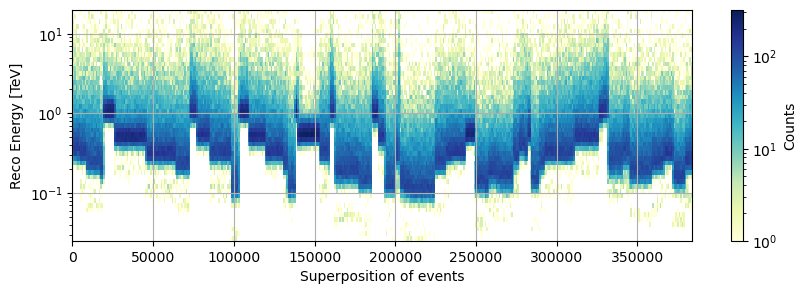

In [8]:
plt.figure(figsize=(10, 3))

hist = plt.hist2d(range(len(dl3_energy)), dl3_energy, (400, ebins), norm=LogNorm(), cmap="YlGnBu")
#plt.scatter(dl3_tstamp[m_gh95], dl3_energy[m_gh95], marker="x", s=10, color="r", label="$\gamma>0.95$")
#plt.plot((tbins[1:]+tbins[:-1])/2, median_energy, "--", c="k", label="Median")

plt.colorbar(hist[3], label="Counts"); #plt.legend()
plt.yscale("log"); plt.grid()
plt.ylabel("Reco Energy [TeV]"); plt.xlabel("Superposition of events")
plt.show()

---
### Energy range selection
Energy range in which the SED points will be computed and the energy range in which the LC will be integrated in TeV.

In [9]:
e_reco_min, e_reco_max = 0.1, 20 # TeV

The **geometry of the reconstructed energy** and then the one of the true energy axis as well. The true one can have more resolution than the reconstructed one.

In [10]:
# True energy edges
e_true_min, e_true_max = 0.01, 40 # TeV

energy_axis = MapAxis.from_energy_bounds(
    e_reco_min, e_reco_max, nbin=4, per_decade=True, unit="TeV", name="energy"
)
energy_axis_true = MapAxis.from_energy_bounds(
    e_true_min, e_true_max, nbin=5, per_decade=True, unit="TeV", name="energy_true"
)

print(f"Energy axis edges:"); display(energy_axis.edges)

Energy axis edges:


<Quantity [ 0.1       ,  0.16986465,  0.28853998,  0.49012742,  0.83255321,
            1.41421356,  2.40224887,  4.08057155,  6.93144843, 11.77408037,
           20.        ] TeV>

---
Defining the spatial geometry. As no background IRF is provided, for **point.like** analysis the background region will be defined as a OFF region in the sky, that we will compare with the ON region i.e. the region where the source is.

Then we need to define the maker that will compute the regions (`maker_bkg`).
* ON region over the source position.
* OFF region via reflecting the region into the symetrical position of the FoV (using `ReflectedRegionsBackgroundMaker`).

The radius of the regions will change depending on the `RAD_MAX` IRF. <span style="color:red">(Will fail if a DL3 without `RAD_MAX` is passed.)</span> The number of OFF regions need to be selected. The OFF regions are defined *symmetrically over the pointing position*, so the acceptance in the camera is the same for all observations.

* More OFF regions would mean more bakground statistics.
* More OFF regions make it more source *contamination* enters into the OFF region.

I usually use 1 or 3 OFF regions.

---

In [11]:
n_off_regions = 3

Defining the geometry and the wobble regions maker. Here if needed, a exclusion mask can be defined if there is some possible **sources** or emission regions in the field of view.

In [12]:
on_region = PointSkyRegion(source_coord)

on_geom = RegionGeom.create(region=on_region, axes=[energy_axis])
geom_image = on_geom.to_image()

region_finder = WobbleRegionsFinder(n_off_regions=n_off_regions)
maker_bkg = ReflectedRegionsBackgroundMaker(region_finder=region_finder)

---

Then we create the needed gammapy makers and we run it over the dataset.

* Creating the main maker (`maker`) without selecting `"background"`, because will be created with a separated maker.

* The safe mask (`maker_safe_mask`) will reject data outside of safe conditions, different conditions can be set:

    - "aeff-max": Based on the % of the maximum effective area which data is allowed.
    - "offset-max": Fixed offset cut at a given radius.

---

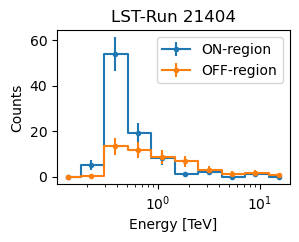

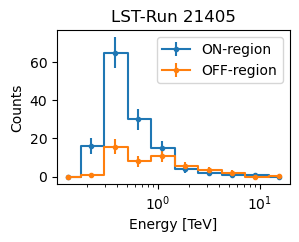

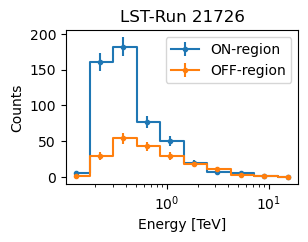

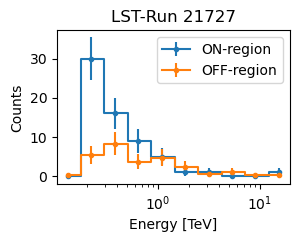

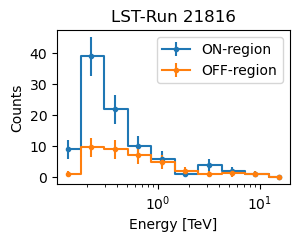

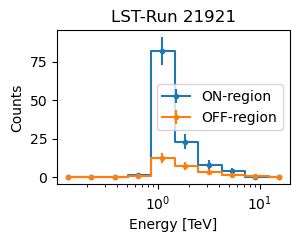

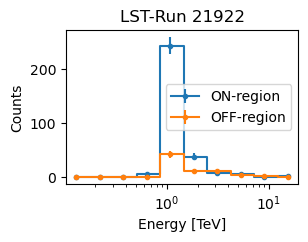

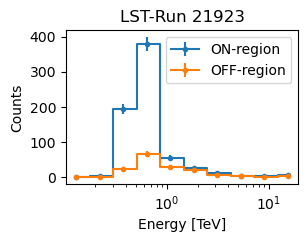

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '21924'.
ReflectedRegionsBackgroundMaker failed. Setting 21924 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '21924': setting `mask_safe` to all False.


Skipping Run 21924: Background estimation failed.


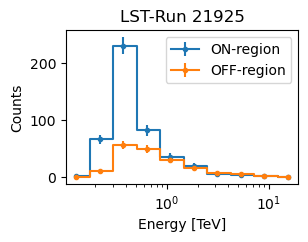

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '21926'.
ReflectedRegionsBackgroundMaker failed. Setting 21926 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '21926': setting `mask_safe` to all False.


Skipping Run 21926: Background estimation failed.


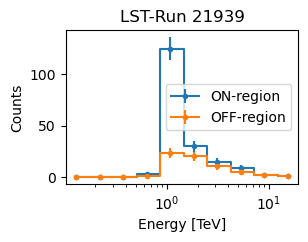

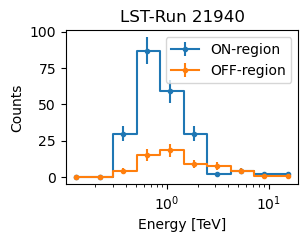

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '21941'.
ReflectedRegionsBackgroundMaker failed. Setting 21941 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '21941': setting `mask_safe` to all False.


Skipping Run 21941: Background estimation failed.


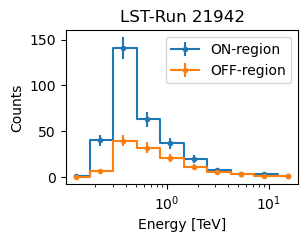

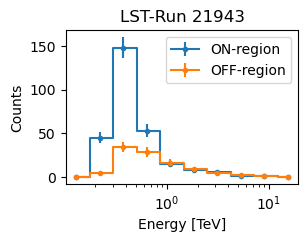

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '21951'.
ReflectedRegionsBackgroundMaker failed. Setting 21951 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '21951': setting `mask_safe` to all False.


Skipping Run 21951: Background estimation failed.


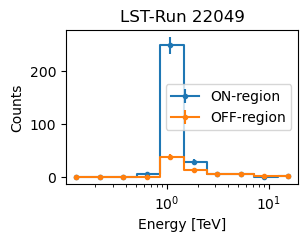

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '22050'.
ReflectedRegionsBackgroundMaker failed. Setting 22050 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '22050': setting `mask_safe` to all False.


Skipping Run 22050: Background estimation failed.


Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '22051'.
ReflectedRegionsBackgroundMaker failed. Setting 22051 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '22051': setting `mask_safe` to all False.


Skipping Run 22051: Background estimation failed.


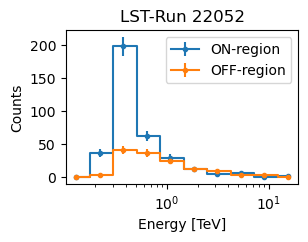

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '22053'.
ReflectedRegionsBackgroundMaker failed. Setting 22053 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '22053': setting `mask_safe` to all False.


Skipping Run 22053: Background estimation failed.


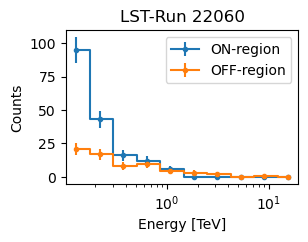

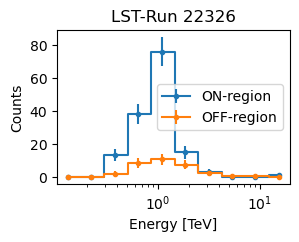

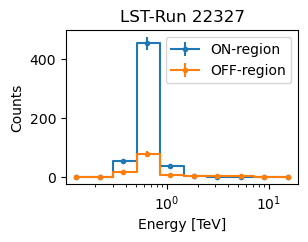

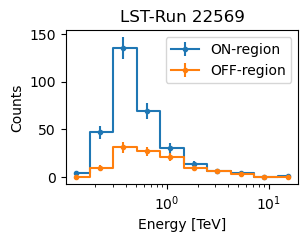

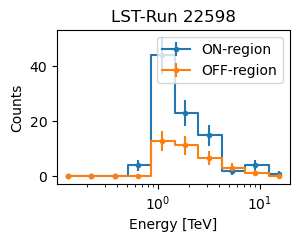

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '22599'.
ReflectedRegionsBackgroundMaker failed. Setting 22599 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '22599': setting `mask_safe` to all False.


Skipping Run 22599: Background estimation failed.


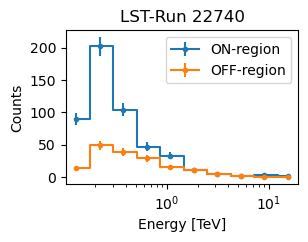

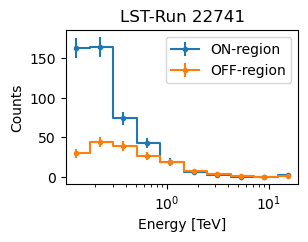

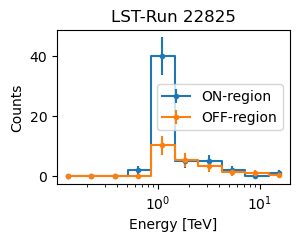

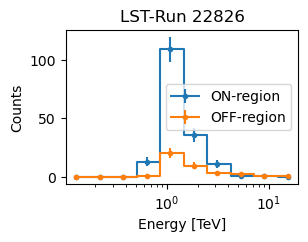

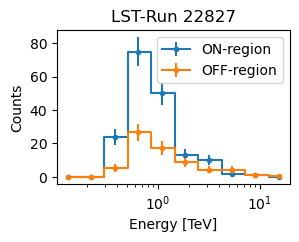

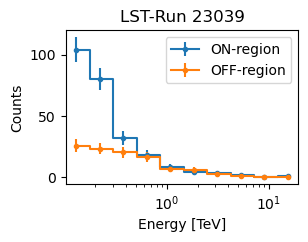

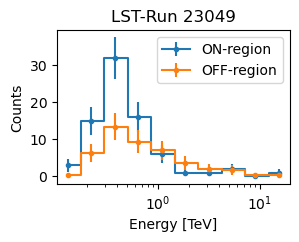

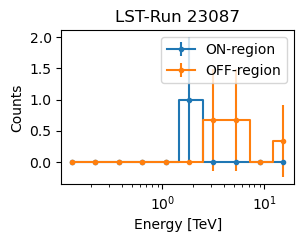

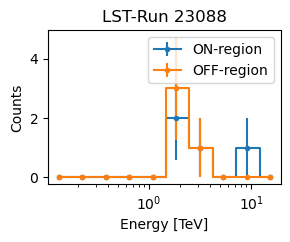

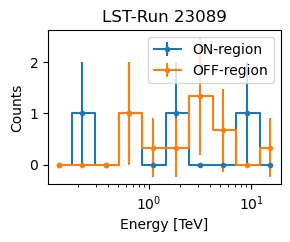

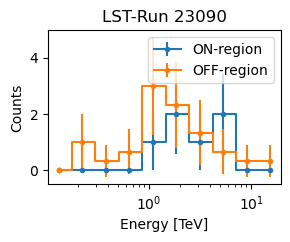

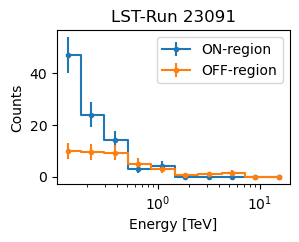

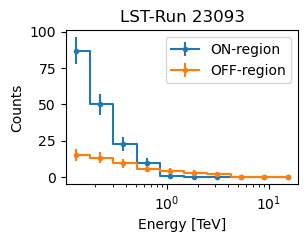

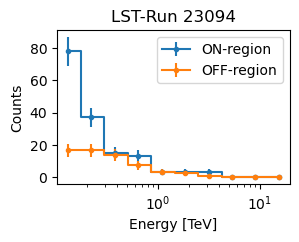

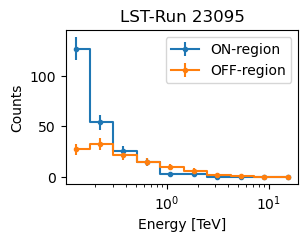

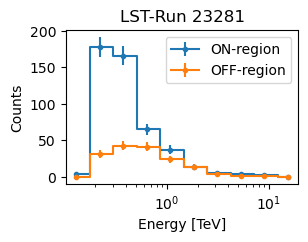

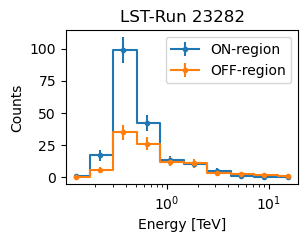

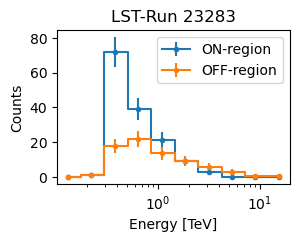

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23284'.
ReflectedRegionsBackgroundMaker failed. Setting 23284 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23284': setting `mask_safe` to all False.


Skipping Run 23284: Background estimation failed.


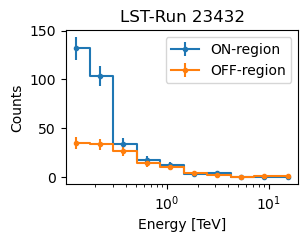

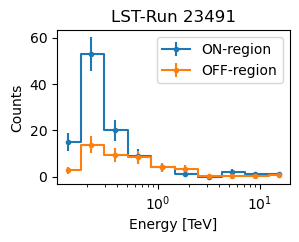

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23492'.
ReflectedRegionsBackgroundMaker failed. Setting 23492 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23492': setting `mask_safe` to all False.


Skipping Run 23492: Background estimation failed.


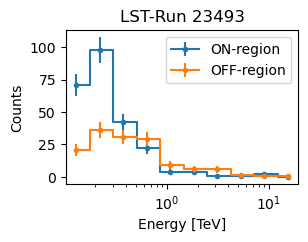

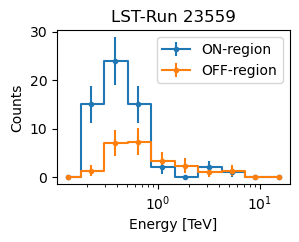

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23560'.
ReflectedRegionsBackgroundMaker failed. Setting 23560 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23560': setting `mask_safe` to all False.


Skipping Run 23560: Background estimation failed.


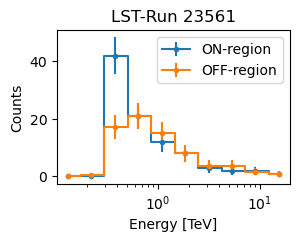

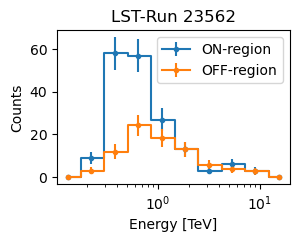

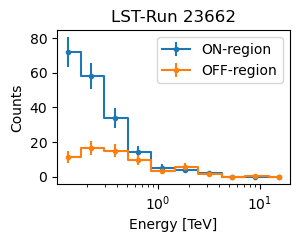

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23666'.
ReflectedRegionsBackgroundMaker failed. Setting 23666 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23666': setting `mask_safe` to all False.


Skipping Run 23666: Background estimation failed.


Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23667'.
ReflectedRegionsBackgroundMaker failed. Setting 23667 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23667': setting `mask_safe` to all False.


Skipping Run 23667: Background estimation failed.


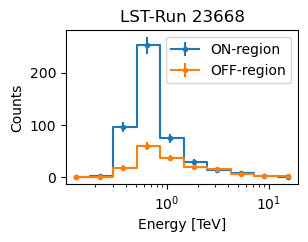

Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23669'.
ReflectedRegionsBackgroundMaker failed. Setting 23669 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23669': setting `mask_safe` to all False.


Skipping Run 23669: Background estimation failed.


Found overlapping on/off regions, choose less off regions
ReflectedRegionsBackgroundMaker failed. No OFF region found outside exclusion mask for dataset '23670'.
ReflectedRegionsBackgroundMaker failed. Setting 23670 mask to False.
Effective area is all zero at [83d37m56.64s 22d01m02.64s]. No safe energy band can be defined for the dataset '23670': setting `mask_safe` to all False.


Skipping Run 23670: Background estimation failed.


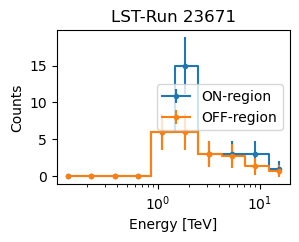

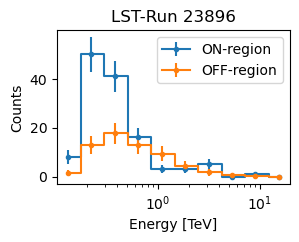

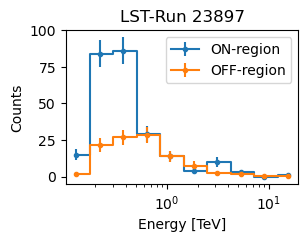

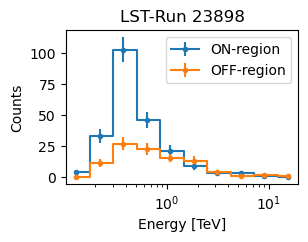

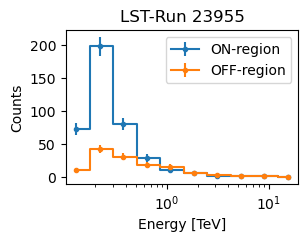

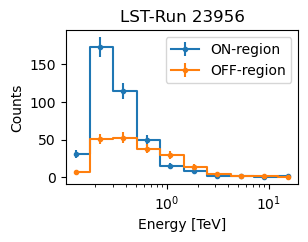

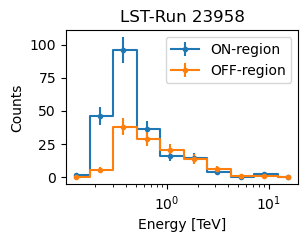

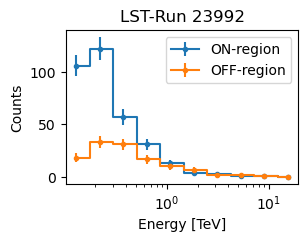

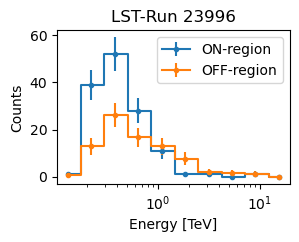

In [20]:
maker = SpectrumDatasetMaker(containment_correction=False, selection=["counts", "exposure", "edisp"])
maker_safe_mask = SafeMaskMaker(methods=["aeff-max"], aeff_percent=5)
# maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=offset_max)

# An empty dataset to fill with the energy and spatia geometry for ON region.
datasets = Datasets()
dataset_empty = SpectrumDataset.create(geom=on_geom, energy_axis_true=energy_axis_true)

for (i, obs_id), obs in zip(enumerate(obs_ids), obs_collection):
    
    dataset = maker.run(dataset_empty.copy(name=str(obs_id)), obs)
    dataset_on_off = maker_bkg.run(dataset=dataset, observation=obs)
    dataset_on_off = maker_safe_mask.run(dataset_on_off, obs)
    
    # Check if counts_off exists before proceeding!
    if dataset_on_off.counts_off is None:
        print(f"Skipping Run {obs_id}: Background estimation failed.")
        continue
        
    datasets.append(dataset_on_off)
    
    # Now this is safe from AttributeError
    c_on = dataset_on_off.counts_off.data.reshape(len(energy_axis.edges)-1)
    alpha = dataset_on_off.alpha.data.reshape(len(energy_axis.edges)-1)
    c_off = dataset_on_off.counts.data.reshape(len(energy_axis.edges)-1) * alpha
    
    fig = plt.figure(figsize=(3, 2))
    plt.errorbar(energy_axis.center, c_on, yerr=np.sqrt(c_on), marker=".", ds="steps-mid", label="ON-region")
    plt.errorbar(energy_axis.center, c_off, yerr=np.sqrt(c_off), marker=".", ds="steps-mid", label="OFF-region")

    plt.xlabel("Energy [TeV]"); plt.ylabel("Counts")
    plt.xscale("log"); plt.legend(); plt.title(f"LST-Run {obs_id}")
    plt.show()
    
info_table = datasets.info_table(cumulative=True)
stacked_dataset = datasets.copy().stack_reduce()

name,counts,excess,sqrt_ts,background,npred,npred_background,npred_signal,exposure_min,exposure_max,livetime,ontime,counts_rate,background_rate,excess_rate,n_bins,n_fit_bins,stat_type,stat_sum,counts_off,acceptance,acceptance_off,alpha
,,,,,,,,m2 s,m2 s,s,s,1 / s,1 / s,1 / s,,,,,,,,
str7,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,str5,float64,int64,float64,float64,float64
stacked,101,90.66666412353516,12.408448777412582,10.333333015441895,33.000000637024634,33.000000637024634,nan,579.69140625,468669216.0,579.6913919016454,583.9321399033047,0.17423063618156398,0.01782557609065743,0.1564050551554823,10,7,wstat,166.84163280762056,31,7.0,21.000001907348633,0.3333333134651184
stacked,238,188.3333282470703,15.157885489040371,49.66666793823242,96.75000422447911,96.75000422447911,nan,1143.6785888671875,876069824.0,1143.6785452580702,1153.1270165741494,0.20810043257941457,0.043427122196320625,0.16467330704763114,10,8,wstat,280.39685135808276,149,8.0,24.0,0.3333333432674408
stacked,713,549.3333129882812,25.12826753798427,163.6666717529297,301.0000056885182,301.0000056885182,nan,2196.8623046875,1612243328.0,2196.862230220311,2273.092650711545,0.3245538068759538,0.07450019828349294,0.25005360164674123,10,8,wstat,711.6419951454814,491,8.0,24.0,0.3333333432674408
stacked,777,602.3333129882812,26.490336161597316,174.66668701171875,325.250014511868,325.250014511868,nan,2339.570556640625,1697049344.0,2339.570512620051,2424.070671349766,0.33211223846801224,0.07465758611229549,0.25745465235571674,10,8,wstat,781.0460746124937,524,8.0,23.999998092651367,0.3333333730697632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
stacked,8971,6945.0,89.81779443883315,2026.0,3762.25021729804,3762.25021729804,nan,39182.72265625,35185758208.0,40647.668897470656,42039.54127863048,0.22070146316701153,0.049842956680009515,0.17085850648700202,10,10,wstat,8670.159428403025,6078,10.0,30.0,0.3333333432674408
stacked,9393,7304.0,92.56120586252509,2089.0,3915.0002246685267,3915.0002246685267,nan,40336.203125,35754311680.0,41801.149281965016,43248.92917659877,0.22470674039702976,0.0499747025113803,0.17473203788564948,10,10,wstat,9198.12691737183,6267,10.0,30.0,0.3333333432674408
stacked,9712,7567.0,94.41958058014804,2145.0,4036.7502764072196,4036.7502764072196,nan,40970.03125,36216365056.0,42434.975482805035,43911.644055396304,0.22886781221154173,0.05054792598782506,0.17831988622371667,10,10,wstat,9565.562883595676,6435,10.0,30.0,0.3333333432674408


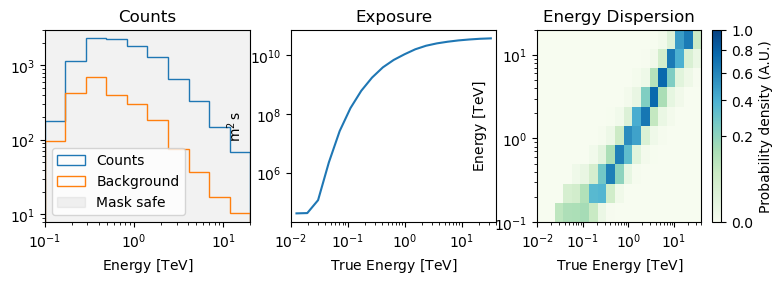

In [21]:
display(info_table)

stacked_dataset.peek(figsize=(9, 2.5))

Plotting the ON and OFF regions selected over the total counts map.

In [22]:
# Getting the counts map
counts = Map.create(skydir=source_coord, width=3, binsz=0.08)
[counts.fill_events(obs.events) for obs in obs_collection]
    
# Getting the maximum RAD_MAX
max_rad_max = np.max(obs_collection[0].rad_max.data.reshape(obs_collection[0].rad_max.data.shape[0])) * u.deg

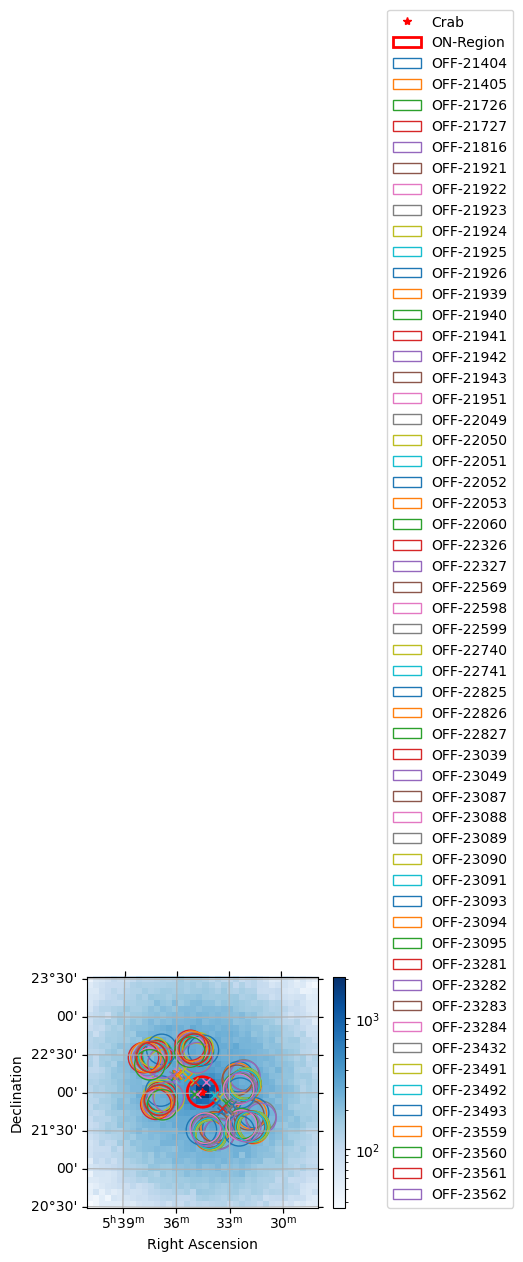

In [23]:
fig = plt.figure(figsize=(4, 3))

ax = counts.plot(add_cbar=True, norm=LogNorm(), cmap="Blues")
ax.plot(source_coord.ra, source_coord.dec, "*r", transform=ax.get_transform("icrs"), label=source_name)

_region = CircleSkyRegion(center=source_coord, radius=max_rad_max)
_on_geom = RegionGeom.create(region=_region, axes=[energy_axis]).plot_region(
    ax=ax, edgecolor="r", lw=2, label="ON-Region"
)

for i, d in enumerate(datasets):
    regions = compound_region_to_regions(d.counts_off.geom.region)
    c_point = SkyCoord(ra=data_store.obs_table[i]["RA_PNT"], dec=data_store.obs_table[i]["DEC_PNT"], unit=u.deg)
    ax.plot(c_point.ra, c_point.dec, "x", transform=ax.get_transform("icrs"))
    
    for j, region in enumerate(regions):
        _region = CircleSkyRegion(center=region.center, radius=max_rad_max)
        _on_geom = RegionGeom.create(region=_region, axes=[energy_axis]).plot_region(
            ax=ax, color=f"C{i}", lw=1, label=f"OFF-{obs_ids[i]}" if (j) == (0) else None
        )

ax.grid(); ax.legend(loc=(1.3, 0))
plt.show()

Checking the excess and significance evolution.

* **Excess vs livetime**: In case of a steady source, the excess will be growing linearly with the livetime.
* **Significance vs square root of livetime**: As significance should be growing quadratically with time. So if we represent the significance vs square root of time, should show a linear behavior.

In [26]:
aS, bS = info_table["excess"], info_table["sqrt_ts"]

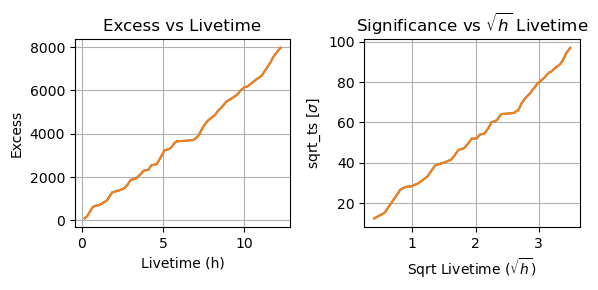

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

ax1.plot(info_table["livetime"].to("h"), aS, ls="-",)
ax2.plot(np.sqrt(info_table["livetime"].to("h")), bS, ls="-",)
ax1.plot(info_table["livetime"].to("h"), info_table["excess"], ls="-",)
ax2.plot(np.sqrt(info_table["livetime"].to("h")), info_table["sqrt_ts"], ls="-",)

ax1.set_xlabel("Livetime (h)"); ax2.set_xlabel(r"Sqrt Livetime ($\sqrt{h}$)")
ax1.set_ylabel("Excess"); ax2.set_ylabel("sqrt_ts [$\sigma$]")

ax1.set_title("Excess vs Livetime"); ax2.set_title("Significance vs $\sqrt{h}$ Livetime")
ax1.grid(); ax2.grid(); fig.tight_layout()

plt.show()

### Defining spectral model

We need to choose the spectral model to be used to fit the data. Here we are **not talking about the spatial model**. As in point-like analysis we are assuming the source position to be fixed we will just need to modify the spectral shape.

##### - Selecting the *pivot energy*

In order to reduce the statistical uncertainty of the parameters of the spectral model a pivot energy need to be selected. So the parameter of dependence will be $(E/E_0)$ instead of $E$ alone. In order to do this we will do it just for the simplest case, the PWL model:
$$
\phi(E) = N \left( \frac{E}{E_{\text{pivot}}} \right)^{-\Gamma}, \qquad N=\phi(E_{\text{pivot}})
$$
Is computed from the covariance matrix, minimizing the correlation between flux $N$ and spectral index $\Gamma$. For more details you can take a look to `DOI-10.1088/0004-637X/707/2/1310`. The decorrelation energy can be computed for any spectral model, but I'll, be using the one for the PWL as a estimation. You can play with the function defined below.


In [28]:
def get_pivot_energy(datasets, e_ref, obj_name):
    """Calculate the decorrelation energy of the fit assuming a Power Law spectral model.
    
    This method (analytical calculation for a power law) is further explained 
    in doi:10.1088/0004-637X/707/2/1310
    """
    # As of Gammapy v1.2, the decorrelation energy can be calculated for any spectral model,
    # so you can change the model below to the one you use later.
    # For previous versions the calculation of the pivot energy was only available
    # (analytically) for the power law model.
    spectral_model = PowerLawSpectralModel(
        index=2, amplitude=2e-11 * u.Unit("cm-2 s-1 TeV-1"), reference=e_ref
    )

    model = SkyModel(spectral_model=spectral_model, name=obj_name)
    model_check = model.copy()

    # Stacked dataset method
    stacked_dataset = Datasets(datasets).stack_reduce()
    stacked_dataset.models = model_check

    fit_stacked = Fit()
    result_stacked = fit_stacked.run(datasets=stacked_dataset)

    return model_check.spectral_model.pivot_energy

In [29]:
ref_energy = get_pivot_energy(datasets, 1*u.TeV, source_name)
print(f"Decorrelation energy used as reference: {ref_energy.to(u.TeV):.2f}")

Decorrelation energy used as reference: 0.95 TeV


Gammapy have different options defined for the different spectral models, see:

https://docs.gammapy.org/dev/user-guide/model-gallery/spectral/index.html

* In order to imporve fitting, is better to set limits to the model parameters.

In [30]:
# spectral_model = PowerLawSpectralModel(index=2, reference=ref_energy)
spectral_model = LogParabolaSpectralModel(reference=ref_energy)

# Putting some limits to the fit parameters
spectral_model.amplitude.min, spectral_model.amplitude.max = 1e-26, 1e-8

# You can freeze some of the parameters: 
# spectral_model.index.frozen = True

model = SkyModel(spectral_model=spectral_model, name=source_name)
display(model.parameters.to_table())

type,name,value,unit,error,min,max,frozen,is_norm,link
str8,str9,float64,str14,int64,float64,float64,bool,bool,str1
spectral,amplitude,1.0000e-12,TeV-1 s-1 cm-2,0.000e+00,1.000e-26,1.000e-08,False,True,
spectral,reference,9.4662e-01,TeV,0.000e+00,nan,nan,True,False,
spectral,alpha,2.0000e+00,,0.000e+00,nan,nan,False,False,
spectral,beta,1.0000e+00,,0.000e+00,nan,nan,False,False,


As a comparison we read or define **Crab model**.

In [31]:
# We also get the Crab Spectral model as a reference
crab_model = create_crab_spectral_model(reference="magic_lp")

# Or crab model from Performance paper
crab_model = LogParabolaSpectralModel(
    amplitude = "3.48e-11 cm-2 s-1 TeV-1",
    reference = 1 * u.TeV,
    alpha = 2.49 * u.Unit(""),
    beta = 0.117 * u.Unit(""),
)

display(crab_model.parameters.to_table())

type,name,value,unit,error,min,max,frozen,is_norm,link
str8,str9,float64,str14,int64,float64,float64,bool,bool,str1
spectral,amplitude,3.4800e-11,TeV-1 s-1 cm-2,0.000e+00,nan,nan,False,True,
spectral,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,False,
spectral,alpha,2.4900e+00,,0.000e+00,nan,nan,False,False,
spectral,beta,1.1700e-01,,0.000e+00,nan,nan,False,False,


# Spectral Energy Distribution estimation

Defining the flux point estimator. When you use the model for the fit, the object itself is modified, so is recomended to use `copy.deepcopy()` just in case you want to perform more than one fit.

In [32]:
fpe = FluxPointsEstimator(
    energy_edges = energy_axis.edges, 
    reoptimize = False,
    source = source_name,
    selection_optional = ["all"],
    n_sigma_ul = 2,
)

fit = Fit()
model_best = copy.deepcopy(model)
datasets.models = model_best
result = fit.run(datasets=datasets)

flux_points = fpe.run(datasets=datasets)
flux_points_dataset = FluxPointsDataset(data=flux_points, models=model_best)

# display(result.minuit)
display(model_best.parameters.to_table())

type,name,value,unit,error,min,max,frozen,is_norm,link
str8,str9,float64,str14,float64,float64,float64,bool,bool,str1
spectral,amplitude,3.3406e-11,TeV-1 s-1 cm-2,5.959e-13,1.000e-26,1.000e-08,False,True,
spectral,reference,9.4662e-01,TeV,0.000e+00,nan,nan,True,False,
spectral,alpha,2.2876e+00,,1.728e-02,nan,nan,False,False,
spectral,beta,1.4984e-01,,1.379e-02,nan,nan,False,False,


You can repeat the same process but for a unique stacked dataset if needed.

In [33]:
# fit_stacked = Fit()
# model_best_stacked = copy.deepcopy(model)
# stacked_dataset.models = model_best
# result_stacked = fit_stacked.run(datasets=stacked_dataset)

# flux_points_stacked = fpe.run(datasets=stacked_dataset)
# flux_points_dataset_stacked = FluxPointsDataset(data=flux_points_stacked, models=model_best_stacked)

So we can plot the **SED** all together with the **residuals**.

In [34]:
# flux_points_datasetS = flux_points_dataset

NameError: name 'flux_points_datasetS' is not defined

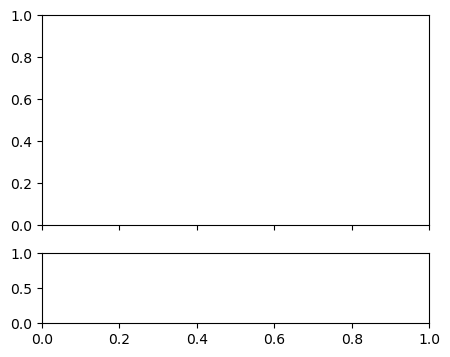

In [35]:
fig, (ax_sed, ax_res) = plt.subplots(2, 1, figsize=(5, 4), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

flux_points_datasetS.plot_spectrum(
    ax=ax_sed, kwargs_fp={"label": "Standard", "color": "k"}, kwargs_model={"ls":"", "label":"", "alpha":0}
)
flux_points_dataset.plot_spectrum(
    ax=ax_sed, kwargs_fp={"label": "Scaled", "color": "r"}, kwargs_model={"ls":"", "label":"", "alpha":0}
)
crab_model.plot(
    ax=ax_sed, sed_type="e2dnde", energy_bounds=[50 * u.GeV, 30 * u.TeV], label="MCP Performance", color="g"
)

flux_points_datasetS.plot_residuals(ax=ax_res, method="diff/model", color="k")
flux_points_dataset.plot_residuals(ax=ax_res, method="diff/model", color="r")

ax_sed.grid(which="both"); ax_res.grid(which="both"); ax_sed.set_xlabel(None)
ax_sed.legend(); ax_res.set_xlim(0.1, 20); ax_sed.set_ylim(3e-12, 2e-10)


plt.tight_layout()
plt.show()

Then you can inspect a bit more deep the statistics in the different bins. Specially for the higher energy you can see how many events you used to compute the upper limit. Gammapy is able to compute the ULs even having zero events in the energy range. Significance of individual points and so...

In [36]:
display(flux_points.to_table(formatted=True, sed_type="flux")[-4:])

e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,ts,sqrt_ts,npred,npred_excess,stat,is_ul,counts,success,norm_scan,stat_scan
TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[55],float32[55],float64,bool,float64[55],bool,float64[11],float64[11]
3.131,2.402,4.081,2.759e-12,1.284e-13,1.301e-13,1.269e-13,3.023e-12,895.124,29.919,7.3825940435668365 .. 8.77478183464442,6.663407 .. 8.473234,148.953,False,9.0 .. 6.0,True,0.200 .. 5.000,624.977 .. 2984.914
5.318,4.081,6.931,1.193e-12,7.841e-14,7.981e-14,7.704e-14,1.356e-12,445.361,21.104,3.5217757167450627 .. 4.068375090694147,3.5217757 .. 4.068375,96.813,False,4.0 .. 5.0,True,0.200 .. 5.000,348.842 .. 1357.556
9.034,6.931,11.774,4.789e-13,4.640e-14,4.769e-14,4.515e-14,5.771e-13,202.593,14.234,2.1961041799101855 .. 2.269179776338831,1.6158023 .. 1.8222022,69.308,False,5.0 .. 4.0,True,0.200 .. 5.000,193.113 .. 567.486
15.345,11.774,20.000,1.830e-13,2.852e-14,2.971e-14,2.738e-14,2.450e-13,63.794,7.987,0.6417619298397642 .. 0.7055592394482159,0.64176196 .. 0.70555925,53.987,False,2.0 .. 0.0,True,0.200 .. 5.000,97.923 .. 222.631


# Light Curve estimation
The Light Curve computation will be computed **based on your SED results**. And therfore is limited by the energy bins used before. Gammapy (at least in v1.1) is only able to integrate full energy bins, so will only roud to the discrete energy bins.

* Is **recomended to do the SED analysis in the same energy range that the LC will be computed**. 
* Or in any case, select the energy bins in a way that you alow for the LC limits needed.

In [37]:
e_lc_min, e_lc_max = 0.1 * u.TeV, 20 * u.TeV
print(f"LC will be estimated from {e_lc_min} to {e_lc_max}")

LC will be estimated from 0.1 TeV to 20.0 TeV


The Light Curve is computed fixing the total SED parameters except the amplitude. Then in a run-wise basis (or other binning distributions can be done) we fit the model with just that one free parameter. This is then converted to **integrated flux**.

Performing the fit using `LightCurveEstimator()` object. We can fit it as well over the stacked dataset so we get a unique estimation using all night information.

In [38]:
# LC makers
lc_maker = LightCurveEstimator(
    energy_edges = [e_lc_min, e_lc_max], 
    reoptimize = False, 
    selection_optional = "all"
)
  
stacked_dataset.models = model_best.copy()

lc_1d = lc_maker.run(datasets)
lc_1d_stacked = lc_maker.run(stacked_dataset)

Value 2.9935046351328344e-16 is outside bounds [2.9935046351328344e-16, 299.3504635132834] for parameter 'norm'
Value 2.9935046351328344e-16 is outside bounds [2.9935046351328344e-16, 299.3504635132834] for parameter 'norm'



Then we can plot the Light Curve.

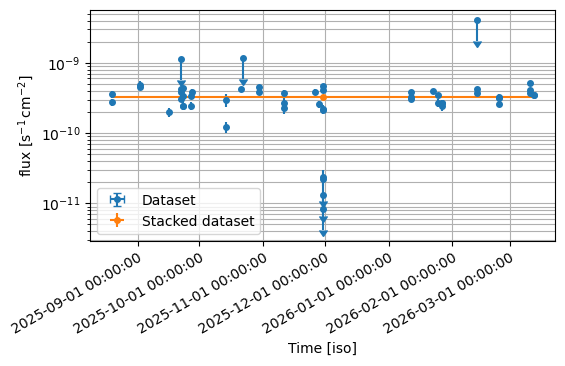

In [39]:
plt.figure(figsize=(6, 3))
lc_1d.plot(sed_type="flux", axis_name="time", label="Dataset")
lc_1d_stacked.plot(sed_type="flux", axis_name="time", label="Stacked dataset")
plt.legend(); plt.grid(which="both")

plt.show()

Again you can get the table and check for more details of every datapoint in the LC.

In [40]:
display(lc_1d.to_table(sed_type="flux", format="lightcurve"))

time_min,time_max,e_ref,e_min,e_max,flux,flux_err,flux_errp,flux_errn,flux_ul,ts,sqrt_ts,npred,npred_excess,stat,is_ul,counts,success,norm_scan,stat_scan
,,TeV,TeV,TeV,1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),1 / (s cm2),,,,,,,,,,
float64,float64,float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],float64[1],"float64[1,55]","float64[1,55]",float64[1],bool[1],"float64[1,55]",bool[1],"float64[1,11]","float64[1,11]"
60906.20967774659,60906.216436220435,1.4142135623730951,0.10000000000000002,19.999999999999996,3.558360609369834e-10,3.9834685896612644e-11,4.111307081412061e-11,3.858365439220206e-11,4.406783756767928e-10,160.93313537877975,12.685942431635883,101.25033240144495 .. nan,91.0013656616211 .. nan,5.908500677293821,False,101.0 .. nan,True,0.2 .. 4.999999999999999,107.38759472747321 .. 317.79833567981456
60906.21679967267,60906.223387576334,1.4142135623730951,0.10000000000000002,19.999999999999996,2.7663232694414567e-10,3.289617166582236e-11,3.3758923821517566e-11,3.204182415053192e-11,3.457889359071146e-10,111.38739228864388,10.55402256434218,nan .. nan,nan .. nan,13.603367593732672,False,nan .. nan,True,0.2 .. 4.999999999999999,76.60716810524437 .. 508.80668743181843
60920.18137381311,60920.19433637832,1.4142135623730951,0.10000000000000002,19.999999999999996,4.5309930463813854e-10,2.7835865759713938e-11,2.8222161356389058e-11,2.745479560938422e-11,5.103257210794847e-10,435.4128477579363,20.86654853486643,nan .. nan,nan .. nan,7.308640469174589,False,nan .. nan,True,0.2 .. 4.999999999999999,317.0621477200008 .. 721.9173665098192
60920.1947144177,60920.1964618485,1.4142135623730951,0.10000000000000002,19.999999999999996,4.764721223467386e-10,7.360632747497893e-11,7.653421673086665e-11,7.078650679576929e-11,6.356813085140542e-10,73.54690860537673,8.57594942880243,nan .. nan,nan .. nan,5.99326156970497,False,nan .. nan,True,0.2 .. 4.999999999999999,59.08808206464375 .. 102.36556912551224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61109.92599920935,61109.93560052563,1.4142135623730951,0.10000000000000002,19.999999999999996,3.6762347451479647e-10,2.804914794038103e-11,2.8541628060850145e-11,2.7563209942595353e-11,4.2572269029314717e-10,298.8568470937643,17.287476597056155,nan .. nan,nan .. nan,7.7811385206014965,False,nan .. nan,True,0.2 .. 4.999999999999999,200.73317469514677 .. 727.7003591111486
61109.935736379826,61109.94973392494,1.4142135623730951,0.10000000000000002,19.999999999999996,4.09654744039563e-10,2.406407563134514e-11,2.443429996450803e-11,2.369779463721277e-11,4.592698808434175e-10,557.5754397034494,23.613035376745817,nan .. nan,nan .. nan,11.130615083020409,False,nan .. nan,True,0.2 .. 4.999999999999999,384.3747628042813 .. 914.8703375284438
61109.96398218769,61109.97165249879,1.4142135623730951,0.10000000000000002,19.999999999999996,5.202242455213034e-10,3.6572558211990144e-11,3.721804727868703e-11,3.594817636971937e-11,5.96133709730546e-10,368.2288288742042,19.189289431195835,nan .. nan,nan .. nan,11.690835673220416,False,nan .. nan,True,0.2 .. 4.999999999999999,281.71560670125905 .. 396.1385742704274


## Task:

Convert the flux values obtained to Crab Units.

In [41]:
flux_crab = crab_model.integral(0.1 * u.TeV, 20 * u.TeV)
e2dnde_crab = crab_model.energy_flux(0.1 * u.TeV, 20 * u.TeV)

fcrab = lc_1d.flux.data.reshape(len(obs_ids)) * lc_1d.flux.unit / flux_crab
ufcrab = lc_1d.flux_err.data.reshape(len(obs_ids)) * lc_1d.flux.unit / flux_crab

ValueError: cannot reshape array of size 55 into shape (70,)

In [ ]:
# fcrabS, ufcrabS = fcrab, ufcrab

In [ ]:
np.std(fcrabS), np.std(fcrab)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 3))
plt.errorbar(np.array(obs_ids, dtype=str), fcrabS, yerr=ufcrabS, marker=".", ls="", capsize=2, color="r", label="Scaled")
plt.errorbar(np.array(obs_ids, dtype=str), fcrab, yerr=ufcrab, marker=".", ls="", capsize=2, color="k", label="Standard")

plt.axhline(1, color="lightgray", ls="--")
plt.legend(frameon=True)
plt.ylabel("Flux [C.U.]")
plt.xlabel("Run Number")
plt.xticks(rotation=90)
plt.show()

In [ ]:
def weighted_average(table, sys_error=0):
    nanmask = ~(np.isnan(table["flux"]) | np.isnan(table["flux_err"]))
    val = table["flux"][nanmask]
    uncertainty = np.sqrt((sys_error * table["flux"][nanmask])**2 + table["flux_err"][nanmask]**2)
    return (val/uncertainty**2).sum() / (1/uncertainty**2).sum(), np.sqrt(1/np.sum(1/uncertainty**2))

def calculate_chi2_pvalue(table, sys_error=0):
    uncertainty = np.sqrt((sys_error * table["flux"])**2 + table["flux_err"]**2)
    flux = table["flux"]
    mean_flux = (flux/uncertainty**2).sum() / (1/uncertainty**2).sum()
    mean_flux_err = np.sqrt(1/np.sum(1/uncertainty**2))
    print(f"Weighted mean flux: {mean_flux:.3e} +/- {mean_flux_err:.3e} cm-2 s-1")
    
    chi2_value = np.sum((table["flux"] - mean_flux)**2/uncertainty**2)
    ndf = len(table["flux"]) - 1
    pvalue = chi2.sf(x=chi2_value, df=ndf)
    print(f"Chi2: {chi2_value:.1f}, ndf: {ndf}, P-value: {pvalue:.2e}")
    return chi2_value, ndf, pvalue

mean_flux = []
mean_flux_err = []

lightcurve = lc_1d.to_table(sed_type="flux", format="lightcurve")

_mean_flux, _mean_flux_err = weighted_average(lightcurve)

_chi2_val, _ndf, _pvalue = calculate_chi2_pvalue(lightcurve, sys_error=0.0)
mean_flux = _mean_flux
mean_flux_err = _mean_flux_err
chi2_val = _chi2_val
pvalue = _pvalue
ndf = _ndf

In [ ]:
def weighted_average(table, sys_error=0):
    nanmask = ~(np.isnan(table["flux"]) | np.isnan(table["flux_err"]))
    val = table["flux"][nanmask]
    uncertainty = np.sqrt((sys_error * table["flux"][nanmask])**2 + table["flux_err"][nanmask]**2)
    return (val/uncertainty**2).sum() / (1/uncertainty**2).sum(), np.sqrt(1/np.sum(1/uncertainty**2))

def calculate_chi2_pvalue(table, sys_error=0):
    uncertainty = np.sqrt((sys_error * table["flux"])**2 + table["flux_err"]**2)
    flux = table["flux"]
    mean_flux = (flux/uncertainty**2).sum() / (1/uncertainty**2).sum()
    mean_flux_err = np.sqrt(1/np.sum(1/uncertainty**2))
    print(f"Weighted mean flux: {mean_flux:.3e} +/- {mean_flux_err:.3e} cm-2 s-1")
    
    chi2_value = np.sum((table["flux"] - mean_flux)**2/uncertainty**2)
    ndf = len(table["flux"]) - 1
    pvalue = chi2.sf(x=chi2_value, df=ndf)
    print(f"Chi2: {chi2_value:.1f}, ndf: {ndf}, P-value: {pvalue:.2e}")
    return chi2_value, ndf, pvalue

mean_flux = []
mean_flux_err = []

lightcurve = lc_1d.to_table(sed_type="flux", format="lightcurve")

_mean_flux, _mean_flux_err = weighted_average(lightcurve)

_chi2_val, _ndf, _pvalue = calculate_chi2_pvalue(lightcurve, sys_error=0.0)
mean_flux = _mean_flux
mean_flux_err = _mean_flux_err
chi2_val = _chi2_val
pvalue = _pvalue
ndf = _ndf

In [4]:
!ls /fefs/aswg/data/mc/IRF/AllSky/20250212_v0.10.17_allsky_interp_dl2_irfs_nsb_0.22/TestingDataset/Gamma/dec_2276/node_theta_10.0_az_102.199_

irf_20240918_v0.10.12_allsky_nsb_tuning_0.22_Gamma_dec_2276_node_theta_10.0_az_102.199_.fits.gz
IRFFITSWriter.provenance.log
job_dl2_to_irfs-43726695.e
job_dl2_to_irfs-43726695.o
lstchain_config_nsb0.22.json


In [7]:
from astropy.io import fits

b = "/fefs/aswg/data/mc/IRF/AllSky/20250212_v0.10.17_allsky_interp_dl2_irfs_nsb_0.22/TestingDataset/Gamma/dec_2276/node_theta_10.0_az_102.199_"

a = fits.open(b+"/irf_20240918_v0.10.12_allsky_nsb_tuning_0.22_Gamma_dec_2276_node_theta_10.0_az_102.199_.fits.gz")

In [9]:
a.info()

Filename: /fefs/aswg/data/mc/IRF/AllSky/20250212_v0.10.17_allsky_interp_dl2_irfs_nsb_0.22/TestingDataset/Gamma/dec_2276/node_theta_10.0_az_102.199_/irf_20240918_v0.10.12_allsky_nsb_tuning_0.22_Gamma_dec_2276_node_theta_10.0_az_102.199_.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  EFFECTIVE AREA    1 BinTableHDU     50   1R x 5C   [25D, 25D, D, D, 25D]   
  2  ENERGY DISPERSION    1 BinTableHDU     56   1R x 7C   [25D, 25D, 30D, 30D, D, D, 750D]   
  3  GH_CUTS       1 BinTableHDU     36   25R x 5C   [D, D, D, K, D]   
  4  RAD_MAX       1 BinTableHDU     50   1R x 5C   [25D, 25D, D, D, 25D]   
